<a href="https://colab.research.google.com/github/Saiful-2/telco-customer-churn/blob/main/notebooks/11_telco_model_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Telecom Customer Churn - Model Evaluation**

In [1]:
# =========================================
# 1. Import Required Libraries
# =========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# =========================================
# 2. Import Evaluation Libraries
# =========================================

from sklearn.metrics import accuracy_score

from sklearn.metrics import precision_score

from sklearn.metrics import recall_score

from sklearn.metrics import f1_score

from sklearn.metrics import classification_report

from sklearn.metrics import confusion_matrix

from sklearn.metrics import roc_curve

from sklearn.metrics import roc_auc_score

from sklearn.metrics import precision_recall_curve

from sklearn.metrics import average_precision_score

In [3]:
# =========================================
# 3. Import Final Selected Model
# =========================================

from sklearn.naive_bayes import GaussianNB

In [4]:
# =========================================
# 4. Load Training Dataset
# =========================================

X_train = pd.read_csv(
'https://raw.githubusercontent.com/Saiful-2/datasets/main/X_train_scaled.csv'
)

y_train = pd.read_csv(
'https://raw.githubusercontent.com/Saiful-2/datasets/main/y_train.csv'
)

In [5]:
# =========================================
# 5. Load Testing Dataset
# =========================================

X_test = pd.read_csv(
'https://raw.githubusercontent.com/Saiful-2/datasets/main/X_test_scaled.csv'
)

y_test = pd.read_csv(
'https://raw.githubusercontent.com/Saiful-2/datasets/main/y_test.csv'
)

In [6]:
# =========================================
# 6. Convert Target Variables into Series
# =========================================

y_train = y_train.squeeze()

y_test = y_test.squeeze()

In [7]:
# =========================================
# 7. Train Final Model
# =========================================

model = GaussianNB()

model.fit(
    X_train,
    y_train
)

GaussianNB()

In [8]:
# =========================================
# 8. Prediction
# =========================================

y_pred = model.predict(X_test)

In [9]:
# =========================================
# 9. Prediction Probability
# =========================================

y_prob = model.predict_proba(X_test)[:,1]

In [10]:
# =========================================
# 10. Accuracy
# =========================================

accuracy_score(
    y_test,
    y_pred
)

0.7420042643923241

In [11]:
# =========================================
# 11. Precision
# =========================================

precision_score(
    y_test,
    y_pred
)

0.5101663585951941

In [12]:
# =========================================
# 12. Recall
# =========================================

recall_score(
    y_test,
    y_pred
)

0.7379679144385026

In [13]:
# =========================================
# 13. F1 Score
# =========================================

f1_score(
    y_test,
    y_pred
)

0.6032786885245902

In [14]:
# =========================================
# 14. Classification Report
# =========================================

print(

classification_report(

y_test,

y_pred

)

)

              precision    recall  f1-score   support

           0       0.89      0.74      0.81      1033
           1       0.51      0.74      0.60       374

    accuracy                           0.74      1407
   macro avg       0.70      0.74      0.71      1407
weighted avg       0.79      0.74      0.75      1407



In [15]:
# =========================================
# 15. Confusion Matrix
# =========================================

cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[768, 265],
       [ 98, 276]])

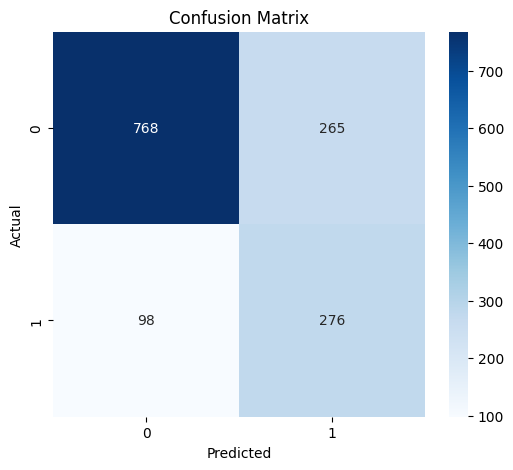

In [16]:
# =========================================
# 16. Confusion Matrix Visualization
# =========================================

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title(
"Confusion Matrix"
)

plt.show()

In [17]:
# =========================================
# 17. ROC Curve
# =========================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

In [18]:
# =========================================
# 18. ROC-AUC Score
# =========================================

auc = roc_auc_score(
    y_test,
    y_prob
)

auc

np.float64(0.8158587469133565)

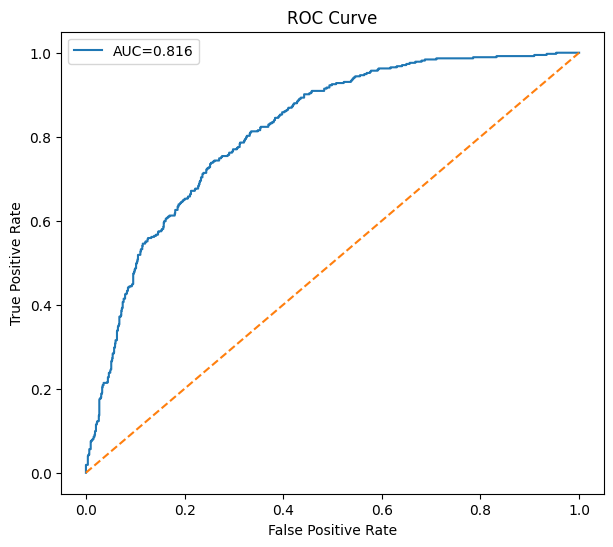

In [19]:
# =========================================
# 19. ROC Curve Visualization
# =========================================

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC={auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel(
"False Positive Rate"
)

plt.ylabel(
"True Positive Rate"
)

plt.title(
"ROC Curve"
)

plt.legend()

plt.show()

In [20]:
# =========================================
# 20. Precision Recall Curve
# =========================================

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

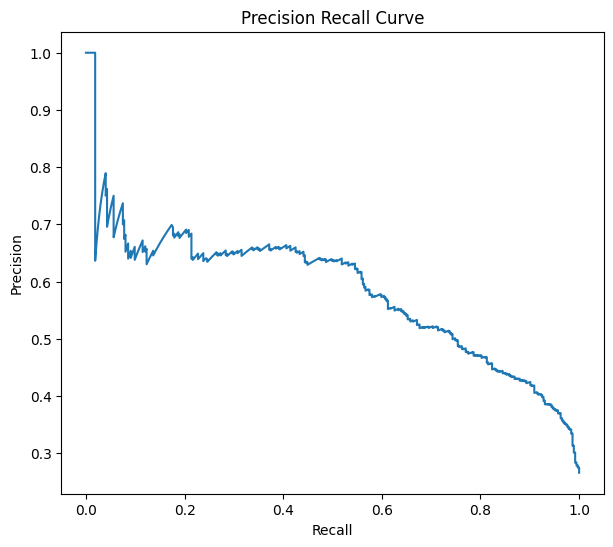

In [21]:
# =========================================
# 21. Precision Recall Curve Visualization
# =========================================

plt.figure(figsize=(7,6))

plt.plot(
    recall,
    precision
)

plt.xlabel(
"Recall"
)

plt.ylabel(
"Precision"
)

plt.title(
"Precision Recall Curve"
)

plt.show()

In [22]:
# =========================================
# 22. Average Precision Score
# =========================================

average_precision_score(
    y_test,
    y_prob
)

np.float64(0.5846080497125813)

In [23]:
# =========================================
# 23. Evaluation Summary Table
# =========================================

evaluation = pd.DataFrame({

'Metric':[

'Accuracy',

'Precision',

'Recall',

'F1 Score',

'ROC AUC'

],

'Score':[

accuracy_score(
y_test,
y_pred
),

precision_score(
y_test,
y_pred
),

recall_score(
y_test,
y_pred
),

f1_score(
y_test,
y_pred
),

auc

]

})

evaluation

,Metric,Score
0,Accuracy,0.742004
1,Precision,0.510166
2,Recall,0.737968
3,F1 Score,0.603279
4,ROC AUC,0.815859


In [24]:
# =========================================
# 24. Business Interpretation
# =========================================

print(
"Higher Recall = Better churn customer detection"
)

print(
"Higher Precision = Fewer false alarms"
)

print(
"F1 balances Precision and Recall"
)

print(
"ROC AUC measures ranking quality"
)

Higher Recall = Better churn customer detection
Higher Precision = Fewer false alarms
F1 balances Precision and Recall
ROC AUC measures ranking quality


In [25]:
# =========================================
# 25. Final Conclusion
# =========================================

print(
"Naive Bayes evaluation completed successfully."
)

Naive Bayes evaluation completed successfully.
